# Fast.ai Unit 1 Mini Project: Image Classifier Core
This is the central notebook for the Fast.ai Practical Deep Learning course **Unit 1 Mini Project**, which is an image classifier designed to classify paintings based on a small subset of well-known artists. These artists are primarily taken from the Impressionistic time period. This is the **local-only, file-based** version of this model, meaning it is not yet available for use in a web environment. 

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from fastai.vision.all import * # fastai image classification
!pip install -Uqq duckduckgo_search==5.3.1b1

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

## Gather data and search for images
For this project we're going to use DuckDuckGo to find some images of Impressionistic paintings. First we'll pull down some sample images of Impressionistic painters, then download larger amounts of images for training the model. 

In [2]:
import time
from duckduckgo_search import DDGS
from fastcore.all import *

def search_images(keywords, max_images=200):
    with DDGS() as ddgs:
        results = list(ddgs.images(keywords, max_results=max_images))
        time.sleep(2)
        return [r['image'] for r in results]

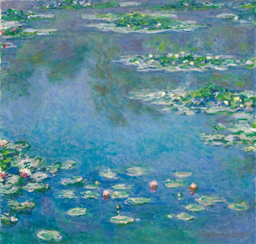

In [3]:
from fastdownload import download_url
from fastai.vision.all import *

# Test to see what kind of results we get when searching for Monet paintings
urls = search_images('monet painting', max_images=1)
urls[0]

dest = 'monet-test-1.jpg'
download_url(urls[0], dest, show_progress=False)

im = Image.open(dest)
im.to_thumb(256,256) # show a preview of the image

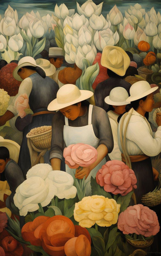

In [9]:
# Do the same thing with a variety of other Impressionistic artists before pulling down mass images to train
urls = search_images('diego rivera painting', max_images=1)
urls[0]

dest1 = 'rivera-test-1.jpg'
download_url(urls[0], dest1, show_progress=False)

im = Image.open(dest1)
im.to_thumb(256,256) # show a preview of the image

In [ ]:
# full list of artists: searches = 'monet', 'renoir', 'rivera', 'degas', 'morisot', 'cassatt', 'cezanne', 'van gogh', 'gauguin', 'manet', 'pissarro', 'seurat', 'toulouse-lautrec', 'whistler', 'turner', 'matisse', 'picasso', 'braque', 'mondrian', 'warhol'

# Pull down photos of the first 5 artists
searches = ['monet', 'renoir', 'rivera', 'degas', 'morisot'] # we have to do only 5 at a time to prevent this from taking forever
path = Path('painting_data')
path.mkdir(exist_ok = True, parents = True)

for name in searches:
    dest = path/name
    dest.mkdir(parents=True, exist_ok=True)

    urls = search_images(f'{name} painting', max_images=200)
    download_images(dest, urls=urls)

In [ ]:
# Pull down photos of the next 5 artists
searches = ['cassatt', 'cezanne', 'van gogh', 'gauguin', 'manet']
path = Path('painting_data')
path.mkdir(exist_ok = True, parents = True)

for name in searches:
    dest = path/name
    dest.mkdir(parents=True, exist_ok=True)

    urls = search_images(f'{name} painting', max_images=200)
    download_images(dest, urls=urls)

In [ ]:
# Pull down photos of the next 5 artists
searches = ['pissarro', 'seurat', 'toulouse-lautrec', 'whistler', 'turner']
path = Path('painting_data')
path.mkdir(exist_ok = True, parents = True)

for name in searches:
    dest = path/name
    dest.mkdir(parents=True, exist_ok=True)

    urls = search_images(f'{name} painting', max_images=200)
    download_images(dest, urls=urls)

In [ ]:
# Pull down photos of the next 5 artists
searches = ['matisse', 'picasso', 'braque', 'mondrian', 'warhol']
path = Path('painting_data')
path.mkdir(exist_ok = True, parents = True)

for name in searches:
    dest = path/name
    dest.mkdir(parents=True, exist_ok=True)

    urls = search_images(f'{name} painting', max_images=200)
    download_images(dest, urls=urls)

## Train the model
We will now proceed to train a **resnet34** classifier model and see how it performs on the given data. The resnet34 classifier is one of the pretrained models offered by PyTorch, and we will create the model using a traditional DataBlock architecture.

In [8]:
# Check to see if any of the images failed to download properly
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

3

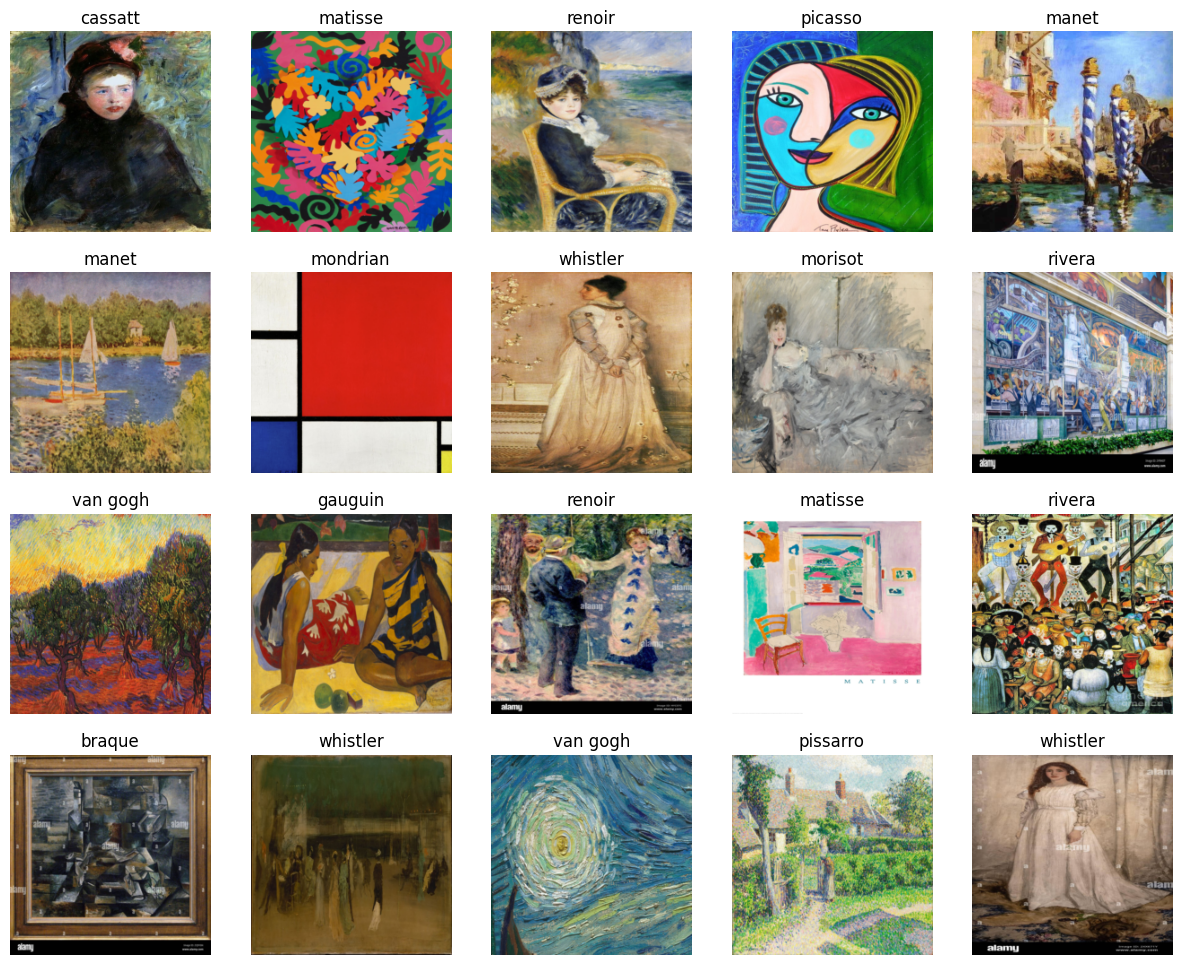

In [50]:
# Create the Datablock
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42), # split 20% of the data off for validation
    get_y=parent_label,
    item_tfms=[Resize(224, method='squish')] # 224x224 image size for capturing more fine details
).dataloaders(path, bs=32)

dls.show_batch(max_n=20) # show a sample of 10 images that the model will be trained upon

# you may notice that very occasionally, one of the images may have Getty or Alamy watermarks on them--we'll leave
# that alone for now, but if it becomes a problem, we'll have to address that issue.

In [ ]:
# Train the resnet34 model
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(3) # train for 3 epochs

# Model reportedly achieved an error rate of 0.156 and a validation loss of 0.57 on most recent train.

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 198MB/s] 


epoch,train_loss,valid_loss,error_rate,time
0,2.661891,0.925712,0.264432,00:58


epoch,train_loss,valid_loss,error_rate,time
0,1.059672,0.650973,0.178771,00:58
1,0.515380,0.606115,0.165736,00:58
2,0.223342,0.570657,0.156425,00:59


## Test the model and make predictions
Here's the most important part of training this painting classifier: making sure it actually works. I've downloaded some randomly-chosen sample images of Impressionistic paintings so it can make predictions, including one by a modern artist, but done in the Impressionistic style.

This is a braque painting.


<Axes: >

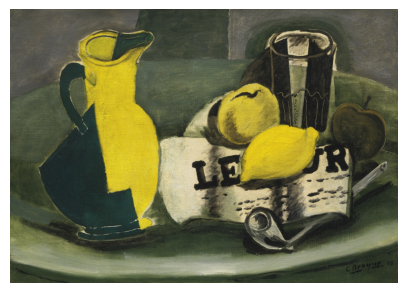

In [53]:
# TODO: possibly add confidence level
# NOTE: although I've saved copies of the test images to the images/ directory in this repository, you'll need to manually upload them to your kaggle/working directory if you're using a Kaggle remote Jupyter server. If you've cloned this repository entirely locally, use 'images/image-name.jpg' in the lines below.

img = PILImage.create('painting-test-8.jpg') # create the image from the directory
classify_painting,_,probs = learn.predict(img)
print(f"This is a {classify_painting} painting.")
show_image(img) # output the image itself

# Notice that for 'painting-test-3.jpeg', which is a painting by modern artist Karen Hale, it decides that it's a Turner painting. Interesting to see what the model chooses when given unfamiliar, but still Impressionistic, paintings.
# Additional note, right now it's giving an incorrect prediction (mondrian) for Henri Matisse's The Bees. Might have to look into this.

In [47]:
# Save this current, very preliminary version of the model just for testing purposes
learn.export('painting_classifier_v1.pkl')